In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader

In [3]:
file_path = r'C:\Users\sharif\Desktop\6.9-Final_AllReactive.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""ETHANOL"").T","STREAMS(""P-ACID"").T","STREAMS(""S15"").T","STREAMS(""C1-INPUT"").T","STREAMS(""S26"").T","STREAMS(""S28"").T","STREAMS(""ETHANOL"").P","STREAMS(""P-ACID"").P","STREAMS(""S15"").P","STREAMS(""C1-INPUT"").P",...,"BLOCKS(""C1"").Stage(29).T","BLOCKS(""C1"").Stage(30).T","BLOCKS(""C1"").Stage(31).T","BLOCKS(""C1"").Stage(32).T","BLOCKS(""C1"").Stage(33).T","STREAMS(""D1"").Zmn(""ETHYL-01"")","STREAMS(""S29"").Zmn(""ETHYL-01"")","STREAMS(""S8"").Zmn(""ETHYL-01"")","STREAMS(""S29"").F","STREAMS(""D1"").F"
0,25.0,25.0,146.692,139.972,25.4830,25.3346,1.01325,1.01325,1.20551,1.20551,...,141.881,142.038,142.194,142.349,142.584,0.933737,0.999927,0.740045,49.0159,287.386
1,25.0,25.0,146.693,139.972,25.4839,25.3356,1.01325,1.01325,1.20552,1.20552,...,141.883,142.039,142.195,142.351,142.585,0.933735,0.999927,0.740045,49.0159,287.387
2,25.0,25.0,146.693,139.972,25.4844,25.3361,1.01325,1.01325,1.20552,1.20552,...,141.884,142.040,142.196,142.352,142.586,0.933733,0.999927,0.740045,49.0159,287.387
3,25.0,25.0,146.693,139.972,25.4846,25.3363,1.01325,1.01325,1.20552,1.20552,...,141.884,142.041,142.197,142.352,142.586,0.933731,0.999927,0.740045,49.0160,287.387
4,25.0,25.0,146.693,139.972,25.4848,25.3365,1.01325,1.01325,1.20553,1.20553,...,141.885,142.041,142.197,142.352,142.586,0.933730,0.999927,0.740045,49.0160,287.387


In [4]:
x = df.iloc[:, :-5].values
y = df.iloc[:, -5:].values 

In [5]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x = scaler_x.fit_transform(x)
y = scaler_y.fit_transform(y)

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
import torch.nn as nn
import math

class MyDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return self.X.shape[0] - self.seq_len + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.seq_len, :]
        y_seq = self.y[idx + self.seq_len - 1, :]
        return x_seq, y_seq

In [8]:
class VALSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(input_dim, hidden_dim * 4))
        self.U = nn.Parameter(torch.Tensor(hidden_dim, hidden_dim * 4))
        self.bias = nn.Parameter(torch.Tensor(hidden_dim * 4))

        self.Wa = nn.Parameter(torch.Tensor(input_dim, input_dim))
        self.Ua = nn.Parameter(torch.Tensor(hidden_dim * 2, input_dim))
        self.ba = nn.Parameter(torch.Tensor(input_dim))
        self.Va = nn.Parameter(torch.Tensor(input_dim, input_dim))
        self.softmax = nn.Softmax(dim=1)

        self.fc = nn.Linear(hidden_dim, output_dim)
        self.hidden_dim = hidden_dim
        self.init_weights()

    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_dim)
        for w in self.parameters():
            w.data.uniform_(-stdv, stdv)

    def forward(self, x):
        batch, seq_len, _ = x.size()
        h_t = torch.zeros(batch, self.hidden_dim).to(x.device)
        c_t = torch.zeros(batch, self.hidden_dim).to(x.device)
        hidden_seq = []
        for t in range(seq_len):
            x_t = x[:, t, :]
            attn = torch.tanh(x_t @ self.Wa + torch.cat([h_t, c_t], dim=1) @ self.Ua + self.ba) @ self.Va
            alpha = self.softmax(attn)
            x_t = alpha * x_t
            gates = x_t @ self.W + h_t @ self.U + self.bias
            i, f, g, o = torch.sigmoid(gates[:, :self.hidden_dim]), torch.sigmoid(gates[:, self.hidden_dim:2*self.hidden_dim]), torch.tanh(gates[:, 2*self.hidden_dim:3*self.hidden_dim]), torch.sigmoid(gates[:, 3*self.hidden_dim:])
            c_t = f * c_t + i * g
            h_t = o * torch.tanh(c_t)
            hidden_seq.append(h_t.unsqueeze(0))
        hidden_seq = torch.cat(hidden_seq, dim=0).transpose(0,1)
        final = hidden_seq[:, -1, :]
        out = self.fc(final)
        return out, alpha

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seq_len = 20
batch_size = 64
epochs = 150
input_dim = x.shape[1]
hidden_dim = 64
output_dim = 5

In [10]:
train_ds = MyDataset(x_train, y_train, seq_len)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [11]:
model = VALSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [12]:
train_losses = []
test_losses = []

In [13]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred, _ = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    x_test_seq = []
    for i in range(len(x_test) - seq_len + 1):
        x_test_seq.append(x_test[i:i+seq_len, :])

    x_test_seq = torch.tensor(np.stack(x_test_seq), dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        preds, _ = model(x_test_seq)
        test_loss = criterion(preds, torch.tensor(y_test[seq_len - 1:], dtype=torch.float32).to(device))
        test_losses.append(test_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss.item():.4f}")

Epoch 1, Train Loss: 0.6578 | Test Loss: 0.2718
Epoch 2, Train Loss: 0.2171 | Test Loss: 0.2296
Epoch 3, Train Loss: 0.2023 | Test Loss: 0.2234
Epoch 4, Train Loss: 0.1969 | Test Loss: 0.2198
Epoch 5, Train Loss: 0.1917 | Test Loss: 0.2119
Epoch 6, Train Loss: 0.1836 | Test Loss: 0.2006
Epoch 7, Train Loss: 0.1574 | Test Loss: 0.1540
Epoch 8, Train Loss: 0.1032 | Test Loss: 0.0860
Epoch 9, Train Loss: 0.0545 | Test Loss: 0.0399
Epoch 10, Train Loss: 0.0334 | Test Loss: 0.0297
Epoch 11, Train Loss: 0.0281 | Test Loss: 0.0279
Epoch 12, Train Loss: 0.0271 | Test Loss: 0.0214
Epoch 13, Train Loss: 0.0119 | Test Loss: 0.0097
Epoch 14, Train Loss: 0.0096 | Test Loss: 0.0082
Epoch 15, Train Loss: 0.0092 | Test Loss: 0.0075
Epoch 16, Train Loss: 0.0069 | Test Loss: 0.0057
Epoch 17, Train Loss: 0.0062 | Test Loss: 0.0058
Epoch 18, Train Loss: 0.0071 | Test Loss: 0.0044
Epoch 19, Train Loss: 0.0040 | Test Loss: 0.0042
Epoch 20, Train Loss: 0.0036 | Test Loss: 0.0060
Epoch 21, Train Loss: 0.0032 

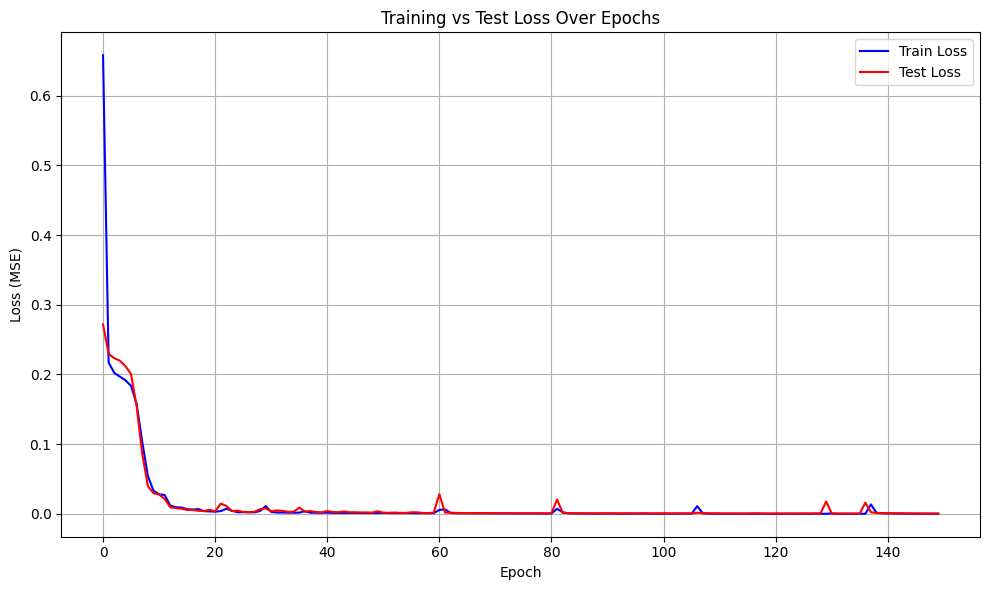

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
y_true = y_test[seq_len - 1:]

# بازگرداندن مقیاس استانداردسازی برای مقایسه‌ی دقیق
y_pred_inv = scaler_y.inverse_transform(preds)
y_true_inv = scaler_y.inverse_transform(y_true)

In [16]:
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # اسامی دقیق رو اینجا جایگزین کن

# ساخت دیکشنری برای DataFrame
data = {}
for i, label in enumerate(labels):
    data[f'Actual {label}'] = y_true_inv[:, i]
    data[f'Predicted {label}'] = y_pred_inv[:, i]

results = pd.DataFrame(data)

print(results.head())

   Actual Target1  Predicted Target1  Actual Target2  Predicted Target2  \
0        0.933322           0.933327        0.999927           0.999927   
1        0.933682           0.933678        0.999927           0.999927   
2        0.933674           0.933685        0.999927           0.999927   
3        0.933701           0.933701        0.999927           0.999927   
4        0.932619           0.932637        0.999927           0.999927   

   Actual Target3  Predicted Target3  Actual Target4  Predicted Target4  \
0        0.740144           0.740149         48.8496          48.852339   
1        0.739934           0.739956         48.9809          48.982943   
2        0.741223           0.741212         48.3745          48.380019   
3        0.739834           0.739825         49.0406          49.043147   
4        0.739419           0.739436         48.8829          48.883684   

   Actual Target5  Predicted Target5  
0         286.417         286.435969  
1         287.185   

In [17]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [18]:
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # به ترتیب: 3 تا غلظت، 2 تا دبی

# تولرانس‌های جداگانه برای هر خروجی
tolerances_per_output = {
    'Target1': [0.001, 0.0001, 0.00005],  # غلظت
    'Target2': [0.001, 0.0001, 0.00005],  # غلظت
    'Target3': [0.001, 0.0001, 0.00005],  # غلظت
    'Target4': [0.02, 0.05, 0.1],             # دبی
    'Target5': [0.02, 0.05, 0.1]              # دبی
}
all_results = {label: [] for label in labels}

In [19]:
# بررسی دقت بر اساس تولرانس‌های اختصاصی هر خروجی
for label_index, label in enumerate(labels):
    print(f"\n--- Accuracy for {label} ---")
    for tol in tolerances_per_output[label]:
        acc = percentage_within_tolerance(y_true_inv[:, label_index], y_pred_inv[:, label_index], tolerance=tol)
        all_results[label].append(acc)
        print(f"Tolerance ±{tol}: {acc:.2f}%")


--- Accuracy for Target1 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 99.55%
Tolerance ±5e-05: 98.38%

--- Accuracy for Target2 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 100.00%

--- Accuracy for Target3 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 99.73%
Tolerance ±5e-05: 99.01%

--- Accuracy for Target4 ---
Tolerance ±0.02: 99.05%
Tolerance ±0.05: 99.82%
Tolerance ±0.1: 99.95%

--- Accuracy for Target5 ---
Tolerance ±0.02: 55.21%
Tolerance ±0.05: 89.86%
Tolerance ±0.1: 98.42%


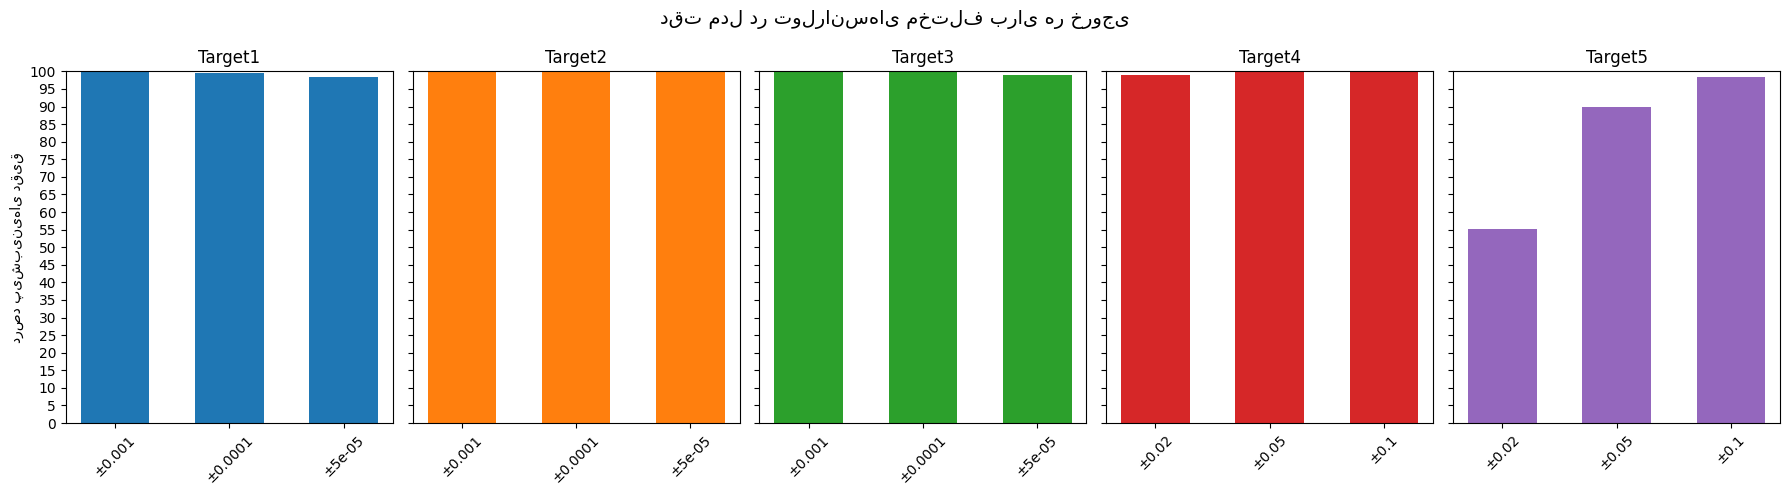

In [20]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# فرض: all_results دیکشنری با مقادیر لیستی از دقت‌ها
# مثل {'Target1': [...], 'Target2': [...], ...}

fig, axs = plt.subplots(1, len(labels), figsize=(18, 5), sharey=True)

for i, label in enumerate(labels):
    accs = all_results[label]
    tols = tolerances_per_output[label]
    
    x = np.arange(len(tols))
    axs[i].bar(x, accs, color=plt.cm.tab10(i), width=0.6)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels([f'±{t}' for t in tols], rotation=45)
    axs[i].set_title(label)
    axs[i].set_ylim(0, 100)
    axs[i].set_yticks(np.arange(0, 101, 5))

axs[0].set_ylabel("درصد پیش‌بینی‌های دقیق")
fig.suptitle("دقت مدل در تولرانس‌های مختلف برای هر خروجی", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true_inv, y_pred_inv)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

In [22]:
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 0.0003595741191613919
MAE: 0.005804407159923086
R2 Score: 0.9994427118043712


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # اسم دقیق متغیرها

for i, label in enumerate(labels):
    mse_i = mean_squared_error(y_true_inv[:, i], y_pred_inv[:, i])
    mae_i = mean_absolute_error(y_true_inv[:, i], y_pred_inv[:, i])
    r2_i = r2_score(y_true_inv[:, i], y_pred_inv[:, i])
    print(f"{label} --> MSE: {mse_i:.4f} | MAE: {mae_i:.4f} | R²: {r2_i:.4f}")

Target1 --> MSE: 0.0000 | MAE: 0.0000 | R²: 0.9996
Target2 --> MSE: 0.0000 | MAE: 0.0000 | R²: 0.9988
Target3 --> MSE: 0.0000 | MAE: 0.0000 | R²: 0.9996
Target4 --> MSE: 0.0000 | MAE: 0.0039 | R²: 0.9996
Target5 --> MSE: 0.0018 | MAE: 0.0251 | R²: 0.9996


Plotting first 100 samples.


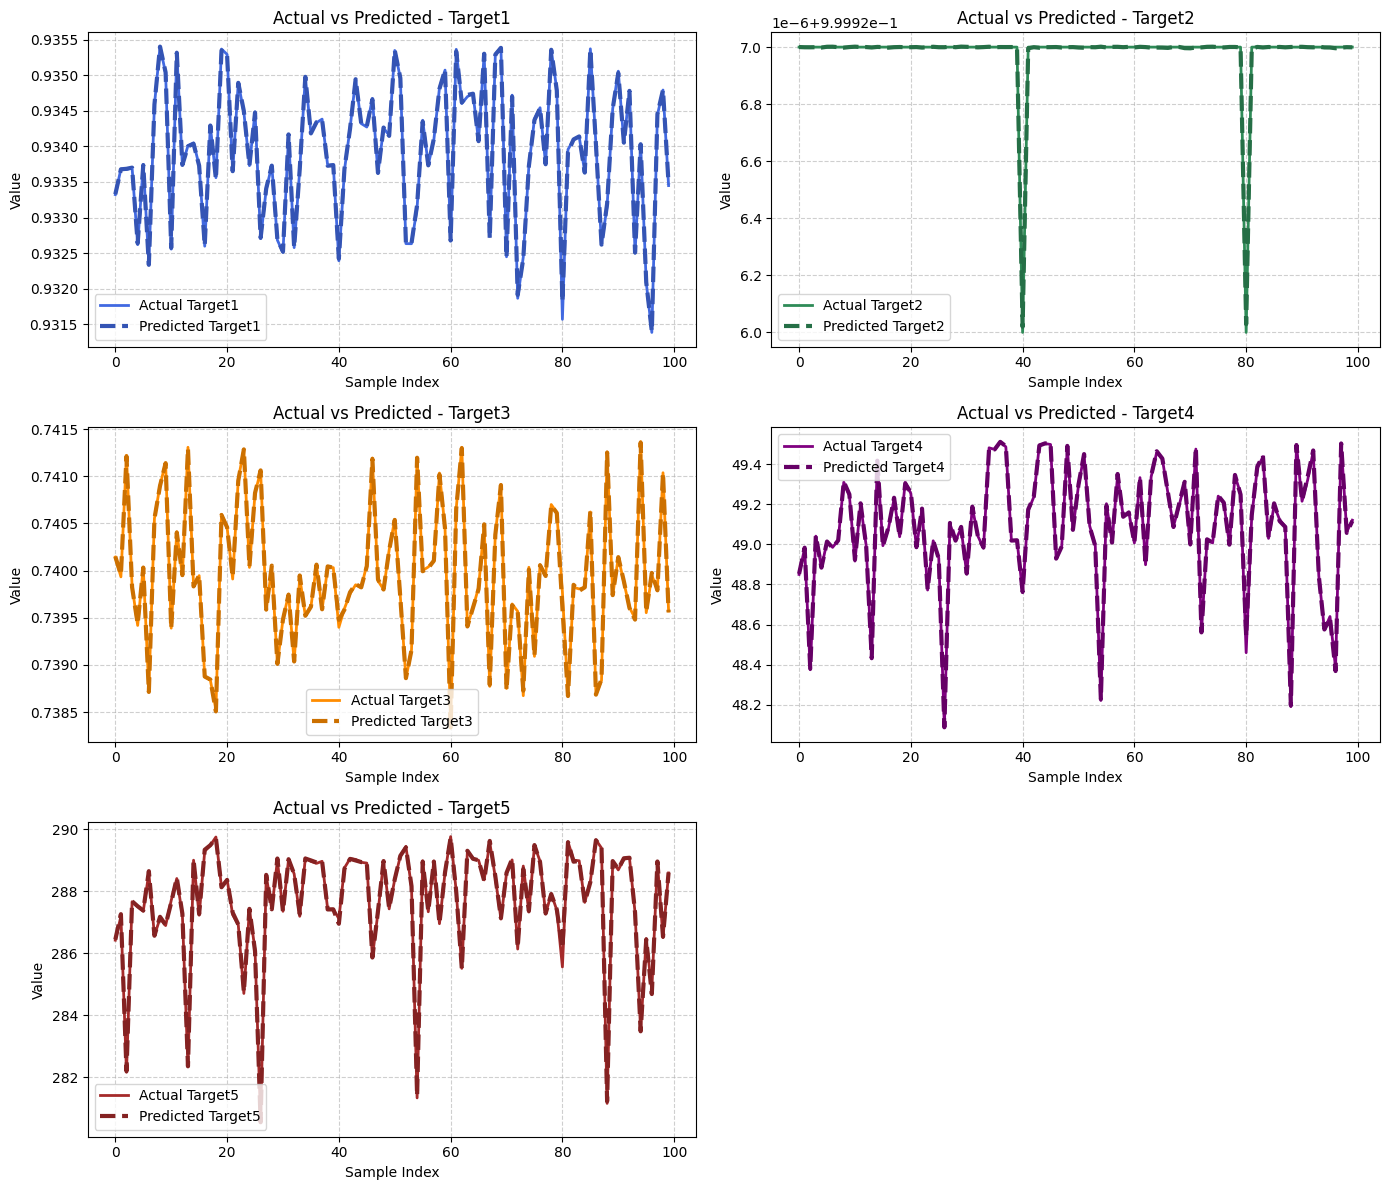

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# رنگ‌های پایه برای هر Target
base_colors = ['royalblue', 'seagreen', 'darkorange', 'purple', 'brown']

# انتخاب زیرمجموعه داده‌ها برای رسم
num_samples = len(results)
max_samples = 100
if num_samples > max_samples:
    subset = results.iloc[:max_samples]
    print(f"Plotting first {max_samples} samples.")
else:
    subset = results
    print("Plotting all available samples.")

plt.figure(figsize=(14, 12))

for i, label in enumerate(labels):
    plt.subplot(3, 2, i + 1)
    
    actual_color = base_colors[i]
    
    # برای رنگ پردیکت، یک رنگ روشن‌تر یا تیره‌تر بساز (مثلا با تغییر روشنایی)
    predicted_color = mcolors.to_rgba(actual_color)
    # می‌تونیم رنگ رو روشن‌تر کنیم:
    predicted_color = (predicted_color[0]*0.8, predicted_color[1]*0.8, predicted_color[2]*0.8, 1)  # کمی تیره‌تر و پررنگ
    
    # رسم Actual: رنگ اصلی، ضخامت نرمال، خط پیوسته
    plt.plot(subset[f'Actual {label}'], label=f'Actual {label}', color=actual_color, linewidth=2)
    
    # رسم Predicted: رنگ تیره‌تر، ضخامت بیشتر، خط‌چین
    plt.plot(subset[f'Predicted {label}'], label=f'Predicted {label}', color=predicted_color, linestyle='--', linewidth=3)
    
    plt.title(f'Actual vs Predicted - {label}')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()